# Overview

The main aim of this project is writing a blog post that answers the following questions from the chosen data set:

a) What are the most important features of the data set, what do they mean, and how do they drive the predicted outcome? 

b) What unusual, or creative, insights are you able to gather from the data set?

c) How accurate is the model that you have trained to predict the data in the data set?

d) What will happen in a creative, predictive, scenario using the model that you have trained?

The purpose of the project is to show that you understand the information presented to you and can explain it in a clear way to an audience.

I focused on solving questions (a) and (b) in the EDA (Exploratory Data Analysis), and questions (c) and (d) in the model development and evaluation.

# Rubrics of the project

## Code

Code is readable (uses good coding practices - PEP8):

- Code has a logical structure and uses comments with markdown effectively. The steps of the data science process (gather, assess, clean, analyze, model, visualize) are clearly identified with comments or Markdown cells, as well. The naming for variables and functions should be according to PEP8 style guide.

Jupyter Notebook is executable and correct:

- All the project code is contained in a Jupyter notebook which can be successfully executed to generate the correct output.

Contains code that is well documented and uses formal code conventions:

Code is well documented and uses functions and classes as necessary. All functions include document strings. DRY principles are implemented.

## Data

Project follows the CRISP-DM Process while analyzing their data.

- Project follows the CRISP-DM process outlined for questions through communication. This can be done in the README or the notebook. If a question does not require machine learning, descriptive or inferential statistics should be used to create a compelling answer to a particular question.

Proper handling of categorical and missing values in the dataset.

- Categorical variables are handled appropriately for machine learning models (if models are created). Missing values are also handled appropriately for both descriptive and ML techniques. Document why a particular approach was used, and why it was appropriate for a particular situation.

## Model

There are 3-5 business questions asked and answered.

- In the Jupyter Notebook, there are between 3-5 questions asked, related to the business or real-world context of the data. Each question is answered with appropriate visualization, table, or statistic.

# Data context

The dataset selected has been provided by https://data.cms.gov/ and it is related to healthcare.

This website is maintained by Centers for Medicare & Medicaid Services (CMS) and contains datasets, tools and more. The United States CMS is a federal agency that provides health coverage to millions of Americans. Their datasets primarily focus on medical facilities that accept Medicare and Medicaid patients.

This site gives everyone direct access to public data released by the CMS. Their goal is to make data readily available in open, accessible, and machine-readable formats.

For most available data, we can:

- Download data in a variety of formats.

- View and analyze data using interactive tools.

- Access data through an Application Programming Interface (https://data.cms.gov/api-docs), or API. An API lets developers connect other applications to data in real time.

The dataset I selected in CMS database is: "Medical Genetics and Genomics Office Visit Cost":

<https://data.cms.gov/provider-data/dataset/b599-54c1#data-table>

Providers inform this dataset contains medical genetics and genomics office visit costs per zip code for new and established patients. It was issued in August 5, 2024, and it has the category "Physician office visit costs (85)".


In [38]:
#%pip install -q --upgrade pip
#%pip install -q pandas
#%pip install -q numpy
#%pip install -q matplotlib
%pip install -q scikit-learn
# imports
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.linear_model import LinearRegression
#from sklSearn.metrics import root_mean_squared_error
#from sklearn.model_selection import train_test_split
#from sklearn.dummy import DummyRegressor

Note: you may need to restart the kernel to use updated packages.


Once I downloaded data, I performed a sanity check:

In [39]:
# get data from the 'houses_clean.csv'. 
# The CSV file is present in the current folder
df = pd.read_csv('Medical_Genetics_and_Genomics.csv')
# sanity check, dataframe check
df.head()

,zip_code,min_medicare_pricing_for_new_patient,max_medicare_pricing_for_new_patient,mode_medicare_pricing_for_new_patient,min_copay_for_new_patient,max_copay_for_new_patient,mode_copay_for_new_patient,most_utilized_procedure_code_for_new_patient,min_medicare_pricing_for_established_patient,max_medicare_pricing_for_established_patient,mode_medicare_pricing_for_established_patient,min_copay_for_established_patient,max_copay_for_established_patient,mode_copay_for_established_patient,most_utilized_procedure_code_for_established_patient
0,210,57.752,174.264,174.264,14.438,43.566,43.566,99205,18.704,142.152,142.152,4.676,35.538,35.538,99215
1,211,57.752,174.264,174.264,14.438,43.566,43.566,99205,18.704,142.152,142.152,4.676,35.538,35.538,99215
2,212,57.752,174.264,174.264,14.438,43.566,43.566,99205,18.704,142.152,142.152,4.676,35.538,35.538,99215
3,213,57.752,174.264,174.264,14.438,43.566,43.566,99205,18.704,142.152,142.152,4.676,35.538,35.538,99215
4,214,57.752,174.264,174.264,14.438,43.566,43.566,99205,18.704,142.152,142.152,4.676,35.538,35.538,99215


I observed labels of the columns were large. Thus, I opted to explore them with detail. First, I printed the labels to know the concepts of each column:

In [40]:
# Columns in the dataset
#print(df.columns.values)
list(df)

['zip_code',
 'min_medicare_pricing_for_new_patient',
 'max_medicare_pricing_for_new_patient',
 'mode_medicare_pricing_for_new_patient',
 'min_copay_for_new_patient',
 'max_copay_for_new_patient',
 'mode_copay_for_new_patient',
 'most_utilized_procedure_code_for_new_patient',
 'min_medicare_pricing_for_established_patient',
 'max_medicare_pricing_for_established_patient',
 'mode_medicare_pricing_for_established_patient',
 'min_copay_for_established_patient',
 'max_copay_for_established_patient',
 'mode_copay_for_established_patient',
 'most_utilized_procedure_code_for_established_patient']

I observed potential categorical and numerical data and I proceeded to explore the values information:

In [41]:
# Print data types (numerical or categorical) and check if there are any missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42966 entries, 0 to 42965
Data columns (total 15 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   zip_code                                              42966 non-null  int64  
 1   min_medicare_pricing_for_new_patient                  42966 non-null  float64
 2   max_medicare_pricing_for_new_patient                  42966 non-null  float64
 3   mode_medicare_pricing_for_new_patient                 42966 non-null  float64
 4   min_copay_for_new_patient                             42966 non-null  float64
 5   max_copay_for_new_patient                             42966 non-null  float64
 6   mode_copay_for_new_patient                            42966 non-null  float64
 7   most_utilized_procedure_code_for_new_patient          42966 non-null  int64  
 8   min_medicare_pricing_for_established_patient          42

I consulted from CMS website that cost metrics (Min, Max, Mode) mean:

- Min Price: The lowest price charged for that medical visit in this zip code.

- Max Price: The highest price charged for that medical visit in this zip code.

- Mode Price: The most frequent price (statistical mode) patients benecied by that service in that region pay.

I also learnt the 'most_utilized_procedure_code_for_new_patient' and 'most_utilized_procedure_code_for_established_patient' correspond to codes we can check online: https://www.cms.gov/medicare/physician-fee-schedule/search?Y=0&T=4&P=1&HT=0&CT=3&H1=99205&M=5

Thus, I should consider 'zip_code', 'most_utilized_procedure_code_for_new_patient' and 'most_utilized_procedure_code_for_established_patient' as categorical values and the rest as numerical values.

Dataset dimensions:

In [42]:
print(f' {df.shape[1]} columns and {df.shape[0]} rows in the dataset.')

 15 columns and 42966 rows in the dataset.


If we consider categorical variables, we would like to know if there are duplicates:

In [43]:
# Study categorical columns and their unique values
categorical_columns = df.select_dtypes(include=['int64']).columns
for col in categorical_columns:
    print(f'Column: {col}, Unique Values: {df[col].nunique()}')
    print(df[col].value_counts())
    print('---')



Column: zip_code, Unique Values: 42966
zip_code
210      1
64132    1
64134    1
64136    1
64137    1
        ..
33010    1
33011    1
33012    1
33013    1
99950    1
Name: count, Length: 42966, dtype: int64
---
Column: most_utilized_procedure_code_for_new_patient, Unique Values: 1
most_utilized_procedure_code_for_new_patient
99205    42966
Name: count, dtype: int64
---
Column: most_utilized_procedure_code_for_established_patient, Unique Values: 1
most_utilized_procedure_code_for_established_patient
99215    42966
Name: count, dtype: int64
---


This means we have a row by zip code, and the same 'most_utilized_procedure_code_for_new_patient' or 'most_utilized_procedure_code_for_established_patient' for all cases. 

If I search the meaning of these codes, they mean:

- '99205' for 'most_utilized_procedure_code_for_new_patient': "Office o/p new hi 60 min" (Office outpatient new patient of high complexity required 60 min face-to-face).

- '99215' for 'most_utilized_procedure_code_for_established_patient': "Office o/p est hi 40 min" (Office outpatient new patient of high complexity required 40-54 min face-to-face; https://www.optimantra.com/medical-code-definitions/cpt-r-code-99215-established-patient-office-visit-40-54-minutes).

This means 'most_utilized_procedure_code_for_new_patient' or 'most_utilized_procedure_code_for_established_patient' variables would not be adequate to develop an EDA nor a model, and I remove them.

In [44]:
# 'most_utilized_procedure_code_for_new_patient' and 'most_utilized_procedure_code_for_established_patient' columns removal
df.drop(['most_utilized_procedure_code_for_new_patient', 'most_utilized_procedure_code_for_established_patient'], axis=1, inplace=True)
# Columns in the dataset
#print(df.columns.values)
list(df)

['zip_code',
 'min_medicare_pricing_for_new_patient',
 'max_medicare_pricing_for_new_patient',
 'mode_medicare_pricing_for_new_patient',
 'min_copay_for_new_patient',
 'max_copay_for_new_patient',
 'mode_copay_for_new_patient',
 'min_medicare_pricing_for_established_patient',
 'max_medicare_pricing_for_established_patient',
 'mode_medicare_pricing_for_established_patient',
 'min_copay_for_established_patient',
 'max_copay_for_established_patient',
 'mode_copay_for_established_patient']

# 1. Exploratory Data Analysis (EDA)

I begin the exploratory data analysis (EDA) by extracting stats from the numerical variables (float values):

In [45]:
# Descriptive Stats
#df.describe()

# We will keep categorical columns as character type and numerical columns as float type.
df2 = df.select_dtypes(include=['float64'])
df2.describe()


,min_medicare_pricing_for_new_patient,max_medicare_pricing_for_new_patient,mode_medicare_pricing_for_new_patient,min_copay_for_new_patient,max_copay_for_new_patient,mode_copay_for_new_patient,min_medicare_pricing_for_established_patient,max_medicare_pricing_for_established_patient,mode_medicare_pricing_for_established_patient,min_copay_for_established_patient,max_copay_for_established_patient,mode_copay_for_established_patient
count,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000,42966.000000
mean,56.037691,170.408565,170.408565,14.009423,42.602141,42.602141,17.913046,138.884824,138.884824,4.478261,34.721206,34.721206
std,3.802850,10.434525,10.434525,0.950713,2.608631,2.608631,1.450066,8.516998,8.516998,0.362516,2.129250,2.129250
min,51.360000,157.744000,157.744000,12.840000,39.436000,39.436000,16.152000,128.776000,128.776000,4.038000,32.194000,32.194000
25%,53.264000,163.240000,163.240000,13.316000,40.810000,40.810000,16.912000,133.296000,133.296000,4.228000,33.324000,33.324000
50%,54.848000,166.888000,166.888000,13.712000,41.722000,41.722000,17.528000,136.112000,136.112000,4.382000,34.028000,34.028000
75%,57.272000,173.088000,173.088000,14.318000,43.272000,43.272000,18.448000,141.112000,141.112000,4.612000,35.278000,35.278000
max,71.336000,222.640000,222.640000,17.834000,55.660000,55.660000,24.016000,181.480000,181.480000,6.004000,45.370000,45.370000


I observed "mode" variables coincide with "max" price charged. 

Next I check for null values and find out all cells had values:

In [46]:
# Check for nulls
df.isna().sum()

zip_code                                         0
min_medicare_pricing_for_new_patient             0
max_medicare_pricing_for_new_patient             0
mode_medicare_pricing_for_new_patient            0
min_copay_for_new_patient                        0
max_copay_for_new_patient                        0
mode_copay_for_new_patient                       0
min_medicare_pricing_for_established_patient     0
max_medicare_pricing_for_established_patient     0
mode_medicare_pricing_for_established_patient    0
min_copay_for_established_patient                0
max_copay_for_established_patient                0
mode_copay_for_established_patient               0
dtype: int64

Common forms of EDAs include generating different plots to understand the skewness of different variables (distribution plots) or to understand how data is distributed (histograms). 

Thus, histograms allow to get an overview of the data.

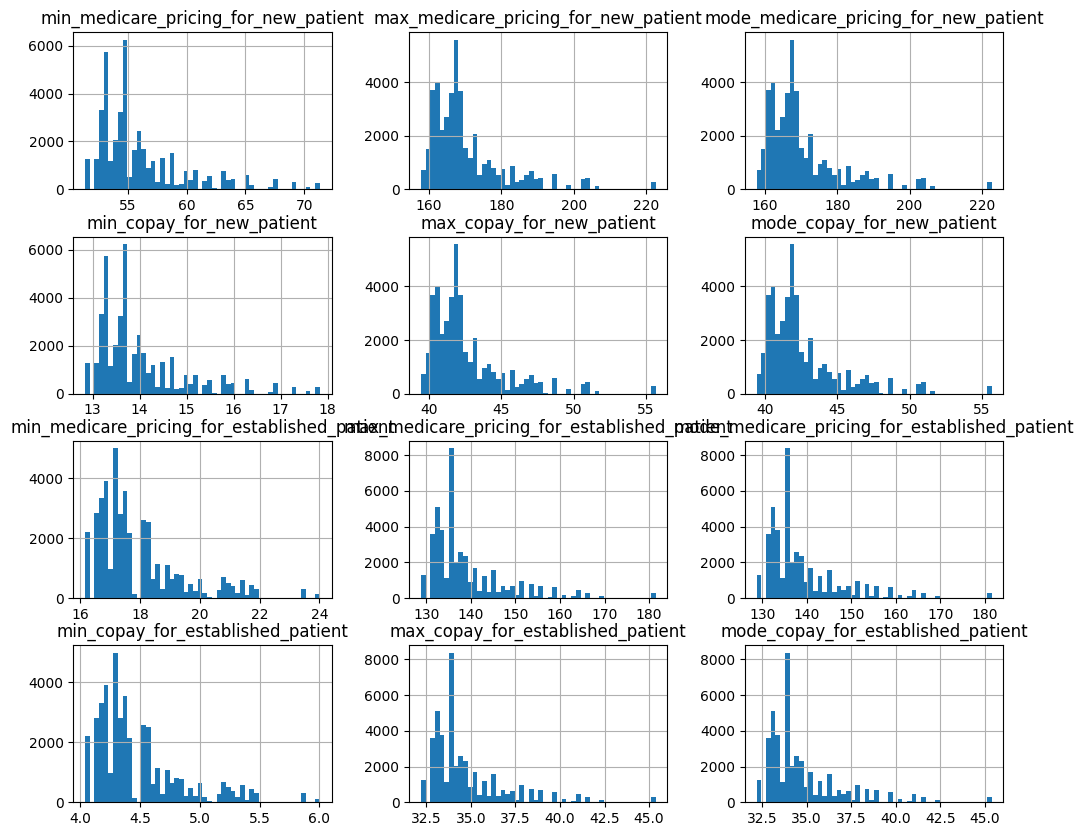

In [47]:
# plot histograms of the features with matplotlib to see their distributions
df2.hist(bins=50, figsize=(12, 10))
plt.show()

In [48]:
# Calculate the correlation matrix of the features
corr_matrix = df.corr()

In [49]:
# Print the correlation matrix sorted by linear correlation with the target
corr_matrix["zip_code"].sort_values(ascending=False)

zip_code                                         1.000000
min_medicare_pricing_for_established_patient     0.039935
min_copay_for_established_patient                0.039935
max_medicare_pricing_for_established_patient     0.008740
mode_medicare_pricing_for_established_patient    0.008740
max_copay_for_established_patient                0.008740
mode_copay_for_established_patient               0.008740
min_medicare_pricing_for_new_patient             0.008327
min_copay_for_new_patient                        0.008327
max_medicare_pricing_for_new_patient            -0.010241
mode_medicare_pricing_for_new_patient           -0.010241
max_copay_for_new_patient                       -0.010241
mode_copay_for_new_patient                      -0.010241
Name: zip_code, dtype: float64

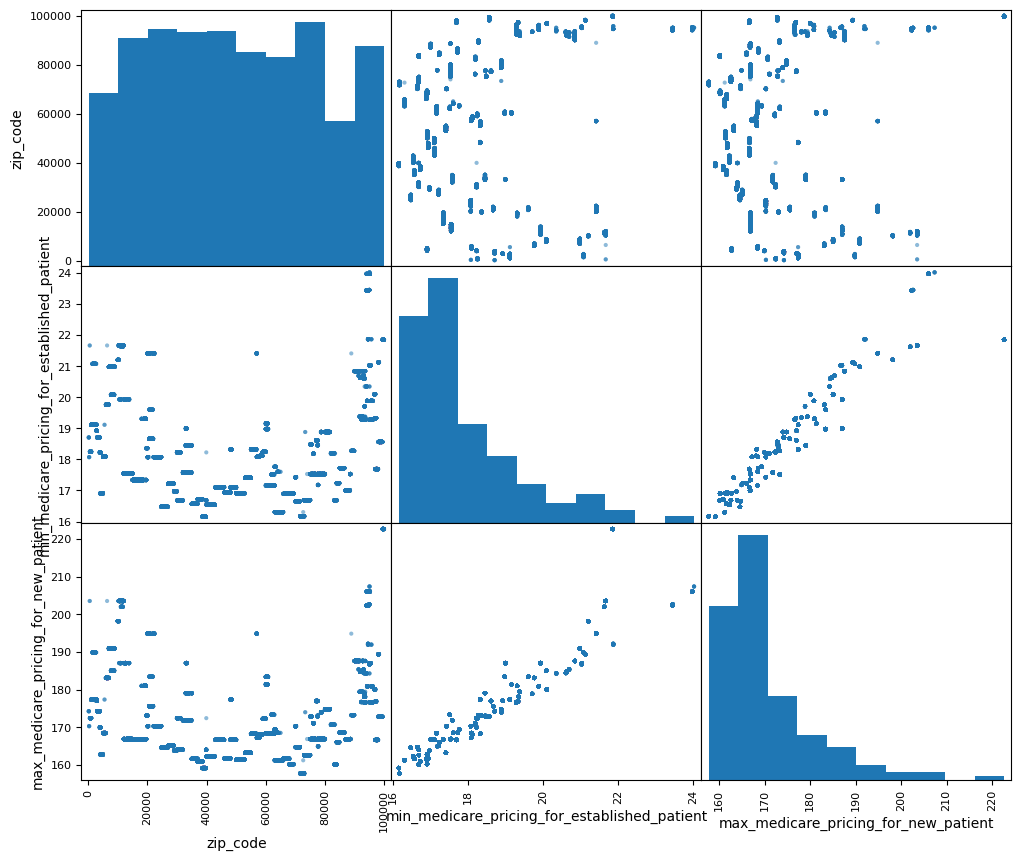

In [50]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix

features = ["zip_code", "min_medicare_pricing_for_established_patient", "max_medicare_pricing_for_new_patient"]

scatter_matrix(df[features], figsize=(12, 10))
plt.show()

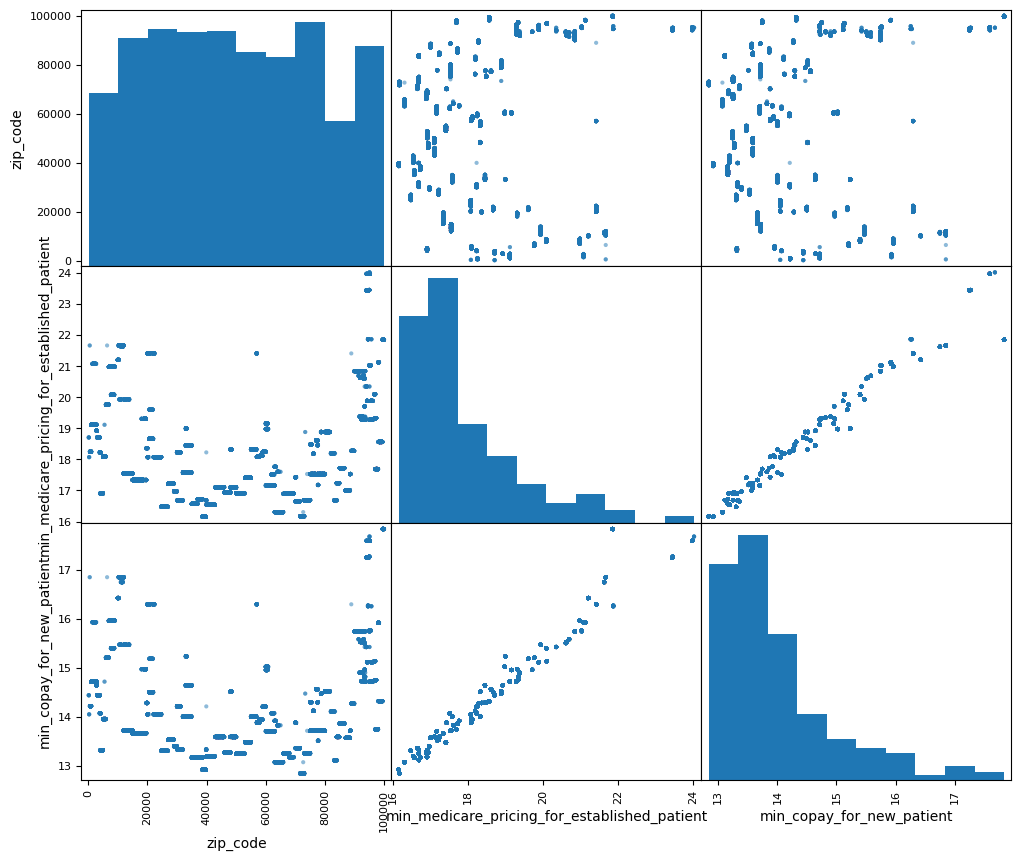

In [51]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix

features = ["zip_code", "min_medicare_pricing_for_established_patient", "min_copay_for_new_patient"]

scatter_matrix(df[features], figsize=(12, 10))
plt.show()

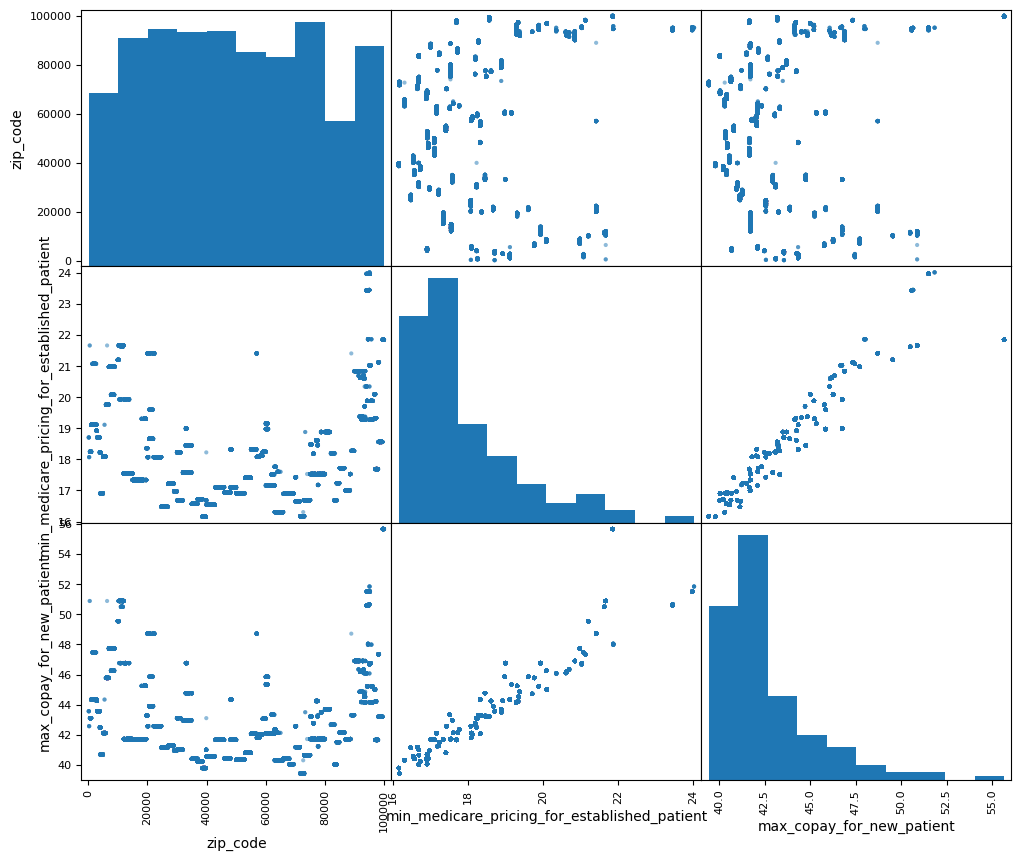

In [52]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix

features = ["zip_code", "min_medicare_pricing_for_established_patient", "max_copay_for_new_patient"]

scatter_matrix(df[features], figsize=(12, 10))
plt.show()

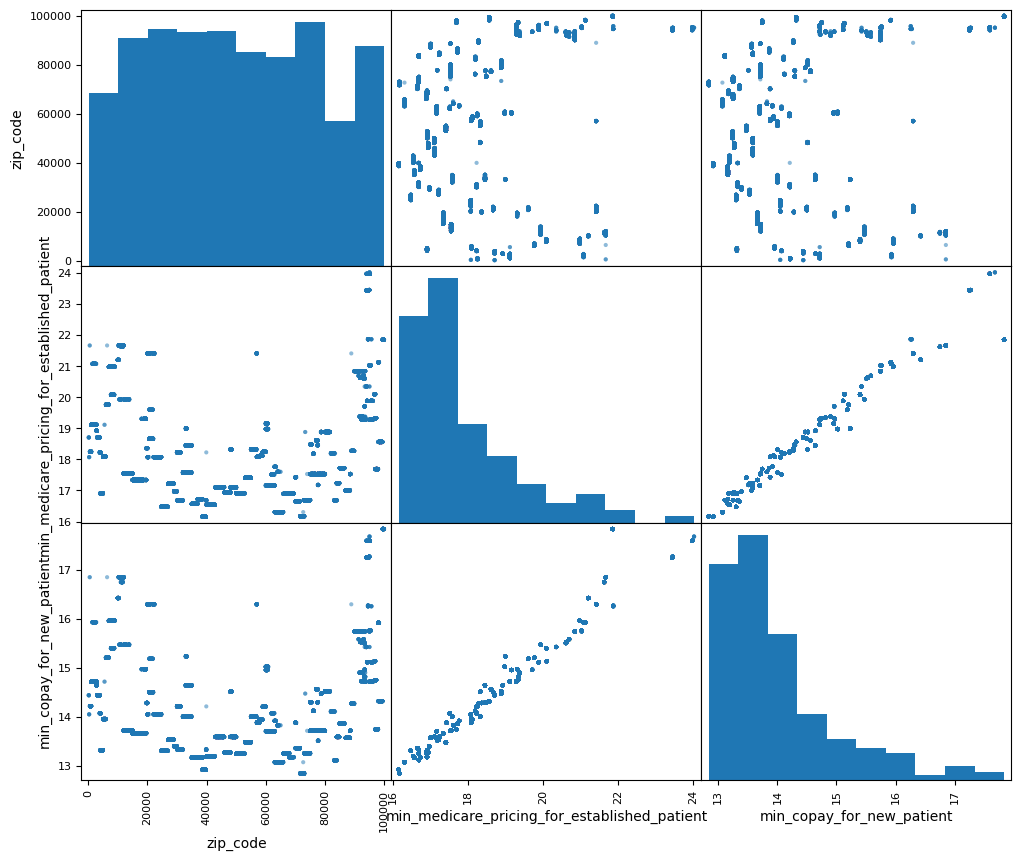

In [53]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix

features = ["zip_code", "min_medicare_pricing_for_established_patient", "min_copay_for_new_patient"]

scatter_matrix(df[features], figsize=(12, 10))
plt.show()

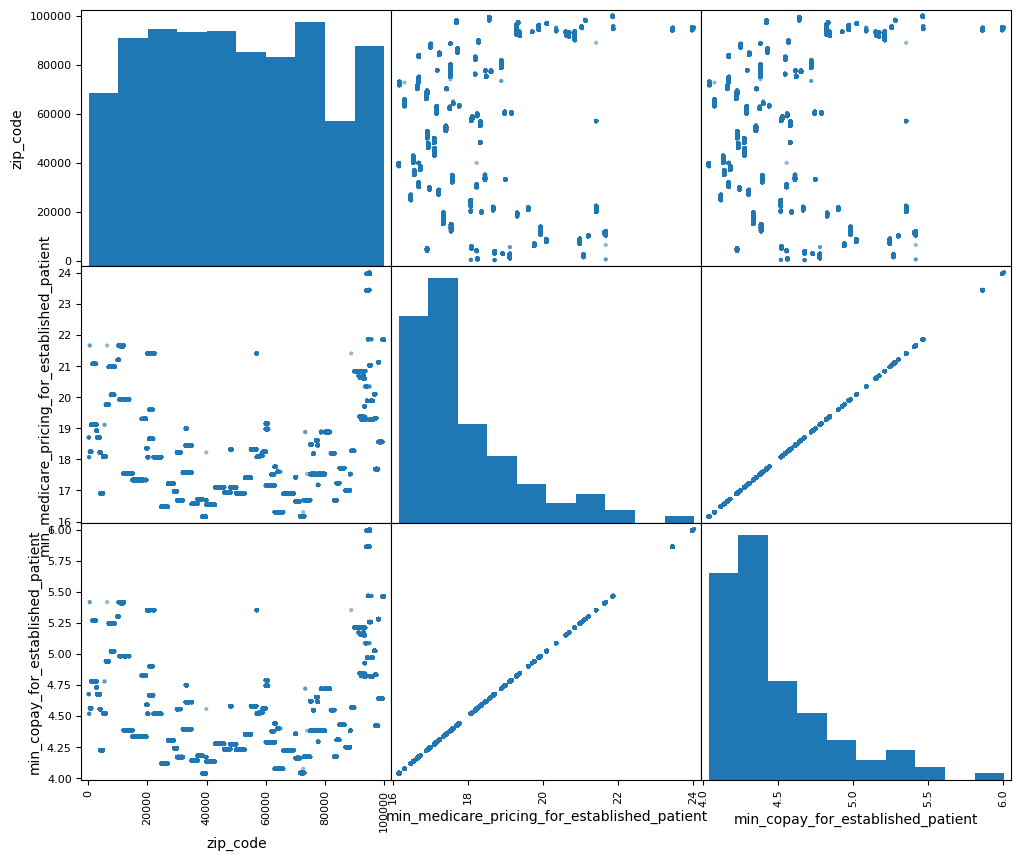

In [54]:
# Plot the most important feature pairs with a scatter plot
from pandas.plotting import scatter_matrix

features = ["zip_code", "min_medicare_pricing_for_established_patient", "min_copay_for_established_patient"]

scatter_matrix(df[features], figsize=(12, 10))
plt.show()

Note: you may need to restart the kernel to use updated packages.


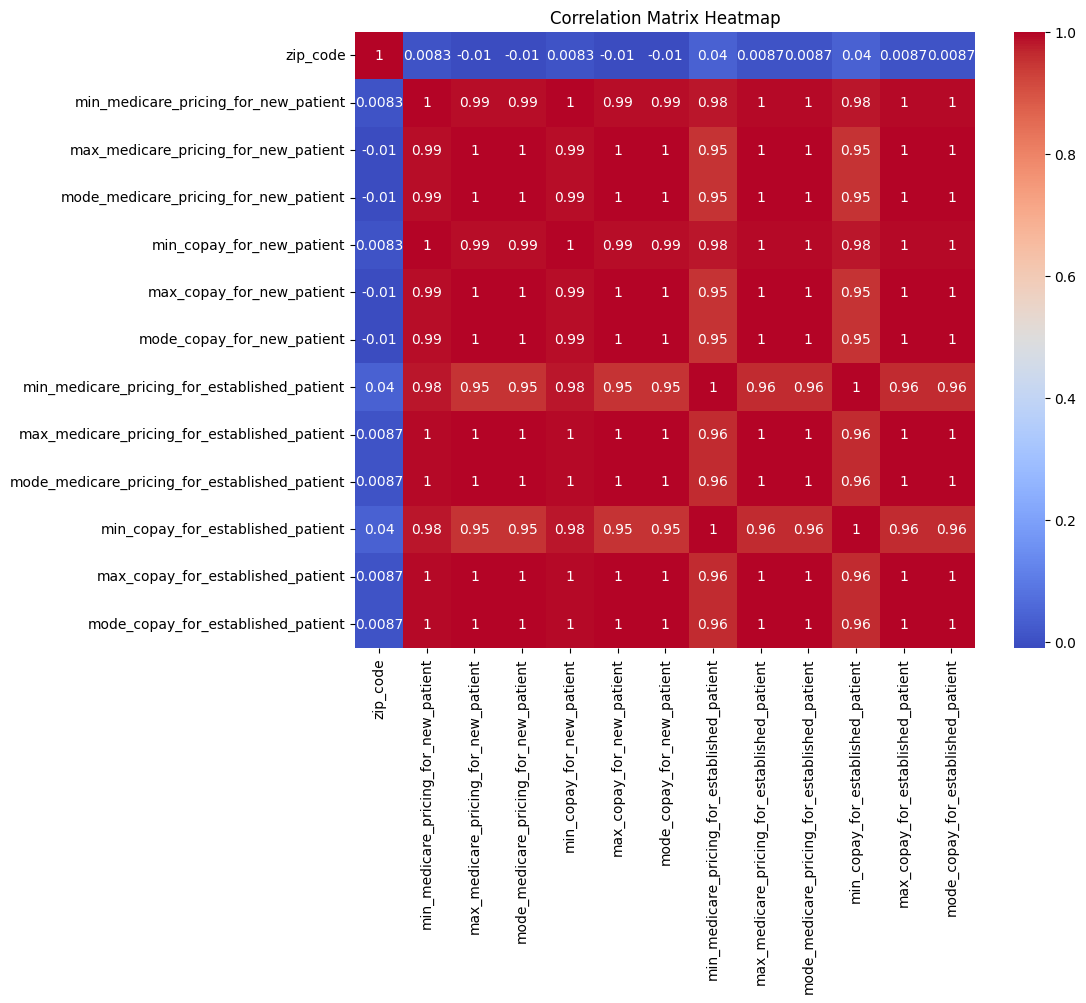

In [55]:
# Plot heatmap of the correlation matrix
%pip install -q seaborn
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

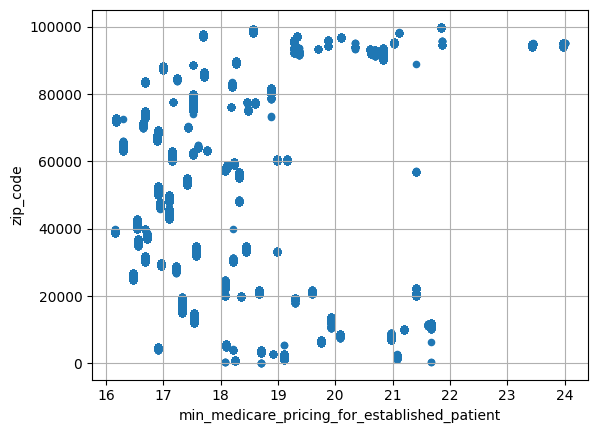

In [56]:
# Choose the most important feature and plot it against the target
df.plot(kind="scatter", x="min_medicare_pricing_for_established_patient", y="zip_code", grid=True)
plt.show()


Alternatively, some data scientists like to perform principal component analyses to better understand the underlying structure of the data.



Performing PCA on the dataset...


/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


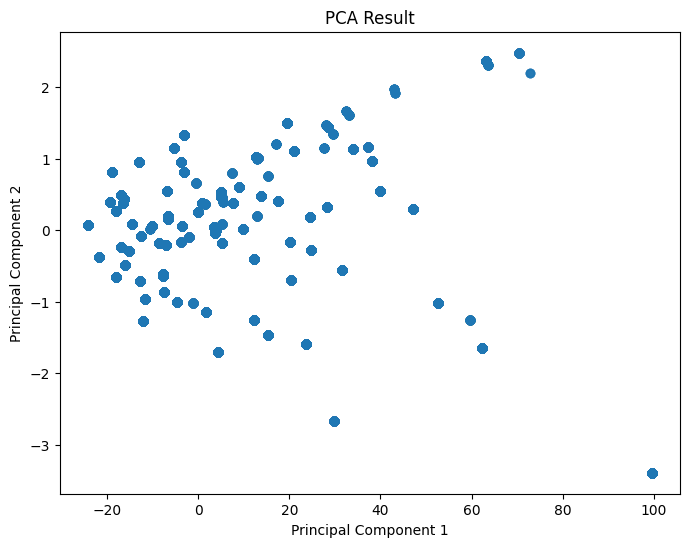

In [57]:
# PCA
print("Performing PCA on the dataset...")
df_numeric = df2.select_dtypes(include=[np.number])
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_numeric) 
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


# 2. Conclusions of EDA

This dataset contains no missing values and is well-structured with 7 features covering Medicare pricing and copay costs across different patient categories (new vs established) for medical generics office visits. The data quality is very good, requiring minimal cleaning.

The EDA leveraged that the dataset is organized by zip code, with consistent procedure codes across all observations. After removing the procedure code columns (which contained only two constant values), I retained pricing-related features that contain meaningful variation for EDA and modeling.

Correlation analysis and scatter plots identified strong relationships between various pricing metrics. Medicare pricing variables show particularly strong correlations with each other, suggesting tha the pricing is often standardized across different cost metrics within regions. The correlation between zip code and pricing variables indicates geographic variation and medical genetics office visit costs.

Histograms also revealed tha tpricing features follow varying distributions, with some showing right-skewed patterns typical of cost data. This suggests data is suitable for modeling but may be benefir from transformations in certain analyses.

PCA demonstrated that data's variation can be effectively captured by a small number of principal components, indicating that underlying patterns in the pricing structure are relatively simple and should be predictable using linear models.

Thus, dataset requires minimal cleaning. No null values are present, and all features are appropriately formatted. The removal of non-informative procedure code columns was already completed. The data is ready for ML model development.

Given the stron correlations between features and the simple underlying structure revealed by PCA, a linear regression model would be appropriate for predicting costs based on available features.

# 3. Machine Learning modeling

Next, the task was training the ML model on the dataset I chose. 

In [58]:
# First, we will separate the features and the target variable. The target variable is 'zip_code', and the features are all other columns in the dataset.
# 'mode_*' columns are exact duplicates of the corresponding 'max_*' columns, which causes perfect
# multicollinearity (a singular XtX matrix), unstable/overflowing coefficients, and NaN predictions.
mode_columns = [col for col in df.columns if col.startswith('mode_')]
X = df.drop(['zip_code'] + mode_columns, axis=1)
y = df['zip_code']
print(f'Features shape: {X.shape}, Target shape: {y.shape}')

Features shape: (42966, 8), Target shape: (42966,)


In [59]:
# Next, we will split the dataset into training and testing sets. We will use 80% of the data for training and 20% for testing.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training X set shape: {X_train.shape}, \nTraining y set shape: {y_train.shape}, \nTesting X set shape: {X_test.shape}, \nTesting y set shape: {y_test.shape}')

Training X set shape: (34372, 8), 
Training y set shape: (34372,), 
Testing X set shape: (8594, 8), 
Testing y set shape: (8594,)


In [60]:
# Now, we will train a linear regression model on the training data.
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Next, I had to evaluate the model for overall accuracy, recall, and other evaluation scores. 

In [61]:
# Now, we will evaluate the model on the testing data. We will use the root mean squared error (RMSE) as the evaluation metric.
# On Apple Silicon, numpy's Accelerate BLAS backend can raise spurious RuntimeWarnings
# (divide by zero/overflow/invalid value) during matmul even when results are finite and correct.
import warnings
from sklearn.metrics import mean_squared_error
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', category=RuntimeWarning)
    y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE) on test set: {rmse}')


Root Mean Squared Error (RMSE) on test set: 26436.649851488135


The RMSE on the test set is approximately 26,437, meaning predictions of `zip_code` are off by about 26,437 units on average. Since zip codes span roughly 10,000 to 99,999, an error of this size is a large fraction of that range, so the model has very limited predictive power.

Based on some scatterplots showed a parabolic trend, I tried a new model:

In [62]:
# Next I test a new model, based on parabolic regression, which is a type of regression that models the relationship between the independent variable and the dependent variable as a second-degree polynomial. This can be useful when the relationship between the variables is not linear.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline 
from sklearn.linear_model import LinearRegression
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train, y_train)


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures()),
                ('linearregression', LinearRegression())])

In [63]:
# Now, we will evaluate the model on the testing data. We will use the root mean squared error (RMSE) as the evaluation metric.
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE) on test set: {rmse}')

Root Mean Squared Error (RMSE) on test set: 26436.649851488135


/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Since the outcome returned the same RMSE, I concluded this poor performance is consistent with the EDA: the correlation matrix showed pricing features have very weak linear correlations with `zip_code` (all below 0.05). Pricing data reflects regional cost-of-living and provider billing patterns, which are not strongly or linearly tied to the numeric value of a zip code itself, so a linear regression struggles to extract a meaningful signal.

In practice, this tells us that `zip_code` is not a good target to predict from these pricing features with a linear model. It would likely make more sense to reverse the problem (predicting pricing from zip code as a categorical/geographic feature) or to use non-linear models if a numeric zip code target is truly required.

# 4. Prediction on a new scenario

In case there was a new scenario that required a prediction from your model to answer, I'd deffinitely would select a different y variable. 

First, I define it as `min_medicare_pricing_for_established_patient`, since I wonder if it would define a limiting expense to make decisions.

In [64]:
# New scenario: I will now test a new model, based on parabolic regression, which is a type of regression that models the relationship between the independent variable and the dependent variable as a second-degree polynomial. This can be useful when the relationship between the variables is not linear.
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
# I select a new y variable, instead of 'zip_code' column:
y = df['min_medicare_pricing_for_established_patient']
# The target column must be excluded from the features, otherwise it leaks into X and the model just learns to copy it.
X_scenario = X.drop(columns=['min_medicare_pricing_for_established_patient'])
X_train, X_test, y_train, y_test = train_test_split(X_scenario, y, test_size=0.2, random_state=42)
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
print(f'Root Mean Squared Error (RMSE) for parabolic regression model on test set: {rmse_poly}')

Root Mean Squared Error (RMSE) for parabolic regression model on test set: 5.715963960446317e-13


/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elenaeyre/Desktop/Science/Courses/Udacity/Data_Science/Course_1/Project_Lesson_6/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


The RMSE for this scenario is about 5.7e-13, effectively zero. At first glance this looks like a perfect model, but such a near-zero error on real-world pricing data is a red flag for data leakage rather than genuine predictive skill.

The likely explanation is that CMS Medicare pricing follows a fixed fee schedule: for a given procedure code, the min, max, and mode Medicare prices (and their copay equivalents) are all deterministic multiples of the same "allowed amount" (we already found copay = medicare_price / 4 and mode = max earlier in the EDA). Since the remaining features still include `max_medicare_pricing_for_established_patient` and the corresponding copay columns, the model can reconstruct `min_medicare_pricing_for_established_patient` almost exactly through simple arithmetic, not because it learned a meaningful relationship between independent business drivers and price.

This means the near-zero RMSE should not be interpreted as "we built an excellent pricing model." It tells us the dataset's pricing columns are mutually redundant (derived from the same underlying fee schedule), so predicting one pricing column from the others is close to solving an algebraic identity. A more meaningful scenario would predict pricing from truly independent features (e.g., geography, procedure complexity) rather than from other pricing columns tied to the same fee schedule.